In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv('C:\\Users\\Sumedha\\OneDrive\\Documents\\Projects\\Placement_prediction\\data\\placementdata.csv')


1. UNDERSTANDING THE DATA

In [7]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [8]:
df.shape

(10000, 12)

In [9]:
df.info()
#no missing values in the dataset

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  str    
 8   PlacementTraining          10000 non-null  str    
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  str    
dtypes: float64(2), int64(7), str(3)
memory usage: 937.6 KB


In [10]:
df.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


In [11]:
df.isnull().sum()

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

2. Data Cleaning

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique()

StudentID                    10000
CGPA                            27
Internships                      3
Projects                         4
Workshops/Certifications         4
AptitudeTestScore               31
SoftSkillsRating                19
ExtracurricularActivities        2
PlacementTraining                2
SSC_Marks                       36
HSC_Marks                       32
PlacementStatus                  2
dtype: int64

In [14]:
df.drop('StudentID',axis=1,inplace=True)
#dropped the column named StudentID as it is not useful for prediction

3. UNIVARIATE ANALYSIS

In [15]:
#checking for categorical columns
df.select_dtypes(include='object').columns

C:\Users\Sumedha\AppData\Local\Temp\ipykernel_416\2317514985.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus'], dtype='str')

In [16]:
print(df['ExtracurricularActivities'].value_counts())
print(df['PlacementTraining'].value_counts())
print(df['PlacementStatus'].value_counts())

ExtracurricularActivities
Yes    5854
No     4146
Name: count, dtype: int64
PlacementTraining
Yes    7318
No     2682
Name: count, dtype: int64
PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64


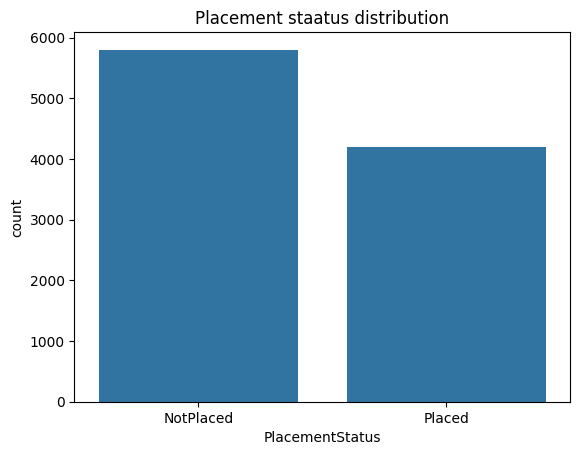

In [17]:
sns.countplot(data=df,x='PlacementStatus')
plt.title('Placement staatus distribution')
plt.show()

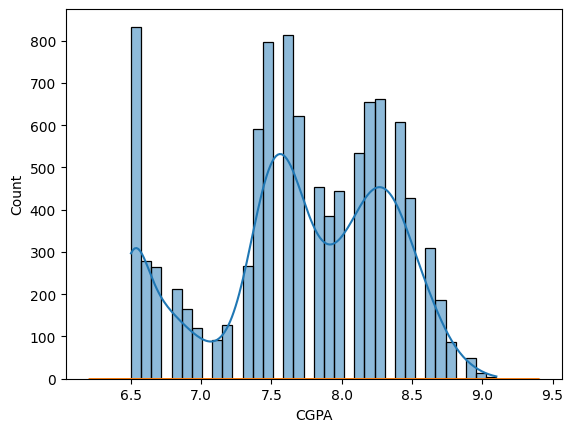

In [18]:
sns.histplot(data=df,x='CGPA',kde=True)
sns.kdeplot(data=df,x='CGPA',fill=True)
plt.show()

In [19]:
numerical_cols = [
    "CGPA","Internships","Projects","Workshops/Certifications","AptitudeTestScore","SoftSkillsRating","SSC_Marks","HSC_Marks"]

C:\Users\Sumedha\AppData\Local\Temp\ipykernel_416\1634975389.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CGPA'])


<Axes: xlabel='CGPA', ylabel='Density'>

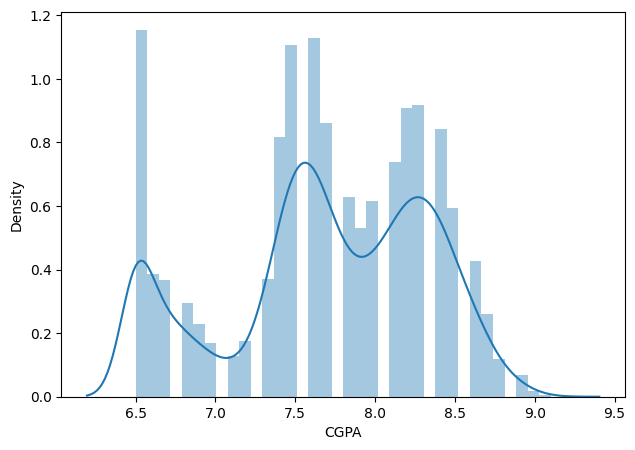

In [20]:
#outliers
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['CGPA'])
#cgpa is not normally distributed and is neither skewed to the left nor to the right
#so we cannot perfrom z score or IQR method to remove outliers from the CGPA column


C:\Users\Sumedha\AppData\Local\Temp\ipykernel_416\771288992.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['HSC_Marks'])


<Axes: xlabel='HSC_Marks', ylabel='Density'>

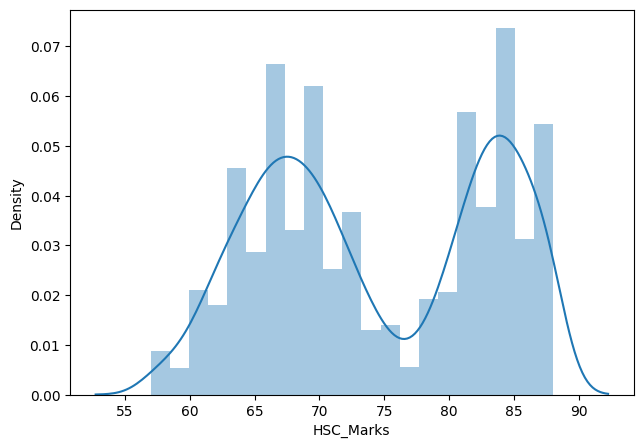

In [21]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['HSC_Marks'])
#HSC_Marks is not normally distributed and is neither skewed to the left nor to the right
#so we cannot perfrom z score or IQR method to remove outliers from the HSC_Marks column

C:\Users\Sumedha\AppData\Local\Temp\ipykernel_416\488873634.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['SSC_Marks'])


<Axes: xlabel='SSC_Marks', ylabel='Density'>

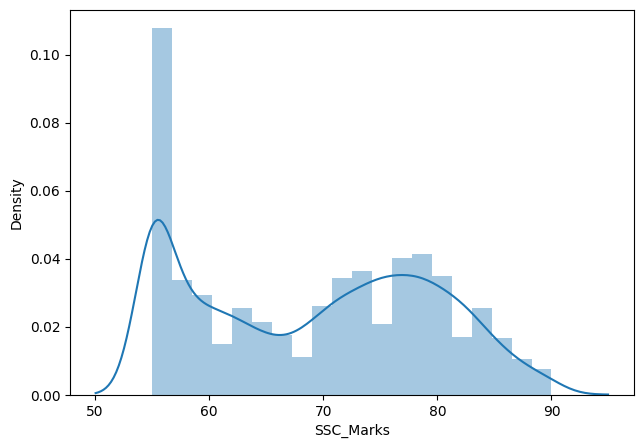

In [22]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['SSC_Marks'])
#SSC_Marks is not normally distributed and is neither skewed to the left nor to the right
#so we cannot perfrom z score or IQR method to remove outliers from the SSC_Marks column

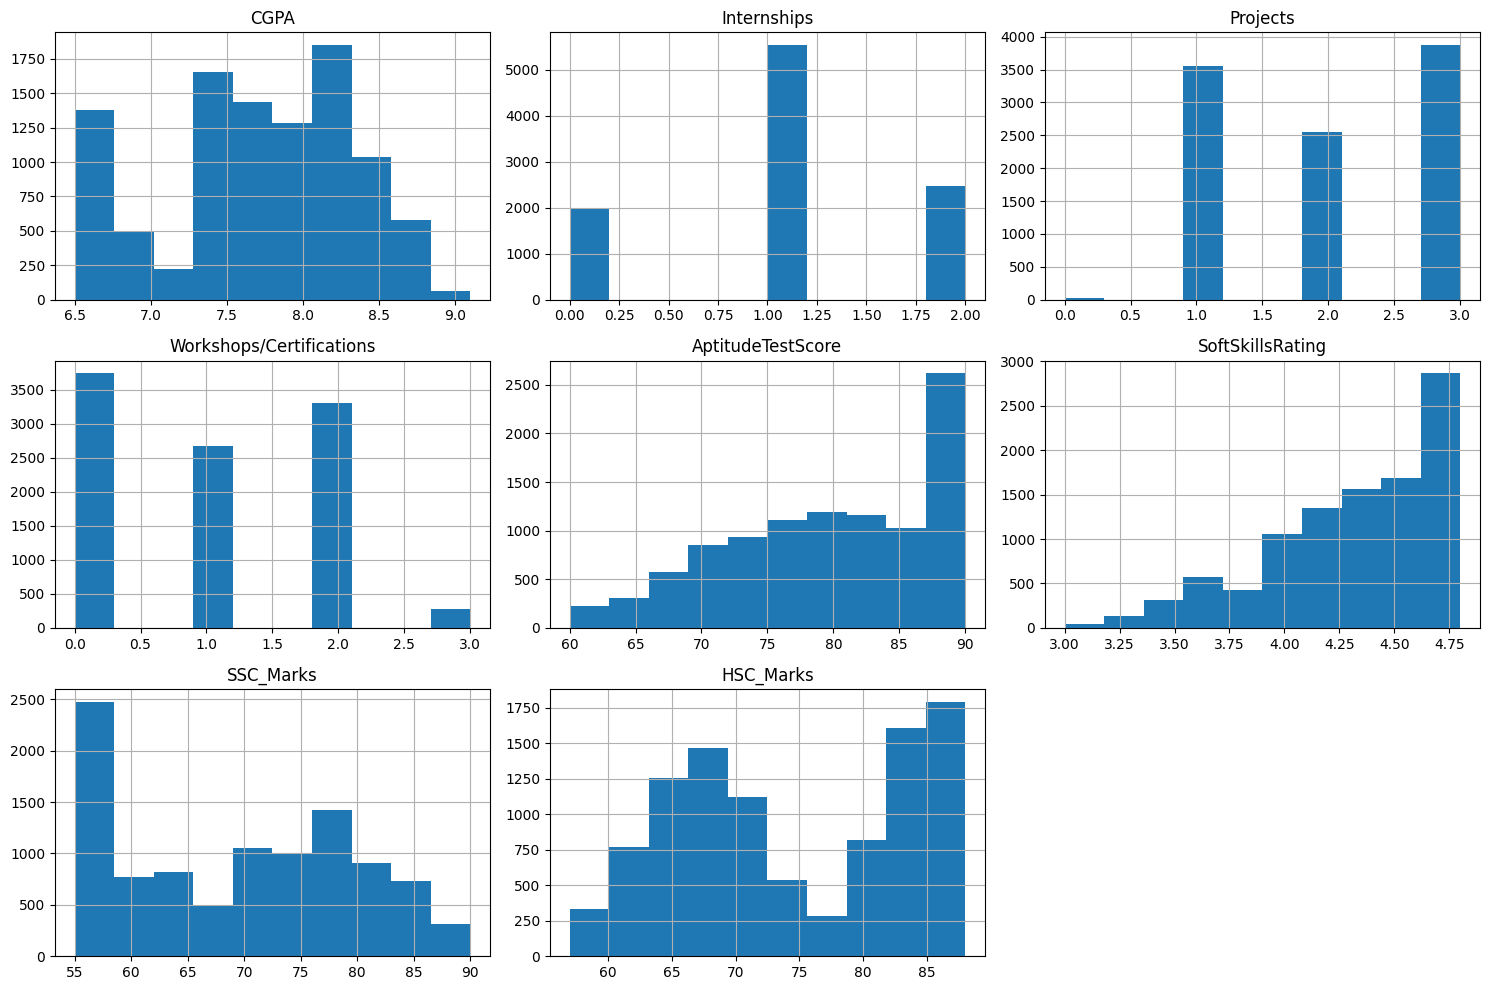

In [23]:
df[numerical_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

<Axes: >

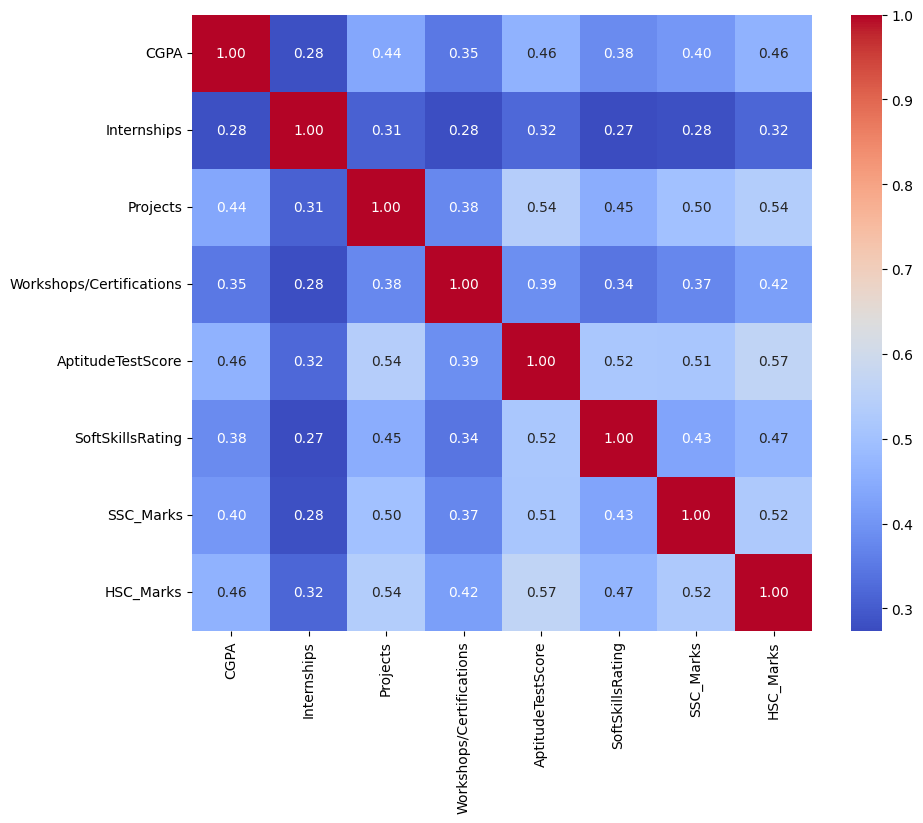

In [24]:
corr=df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,annot=True,cmap="coolwarm",fmt=".2f"
)

4. BIVARIATE ANALYSIS

<Axes: xlabel='PlacementStatus', ylabel='CGPA'>

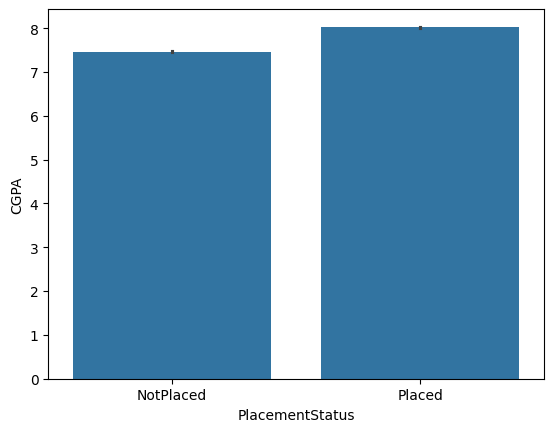

In [25]:
sns.barplot(data=df,x='PlacementStatus',y='CGPA')

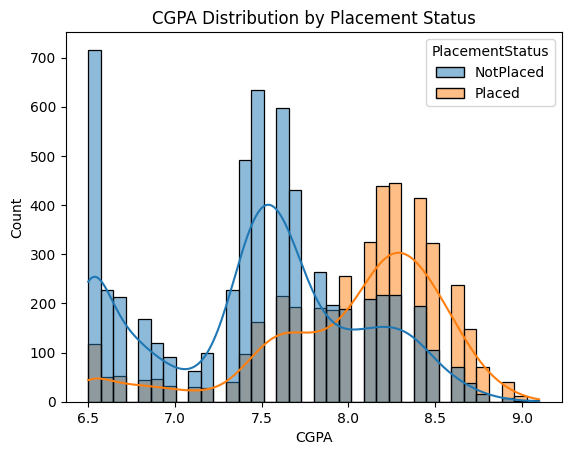

In [26]:
sns.histplot(
    data=df,
    x="CGPA",
    hue="PlacementStatus",
    kde=True
)

plt.title("CGPA Distribution by Placement Status")
plt.show()

<Axes: xlabel='PlacementStatus', ylabel='Internships'>

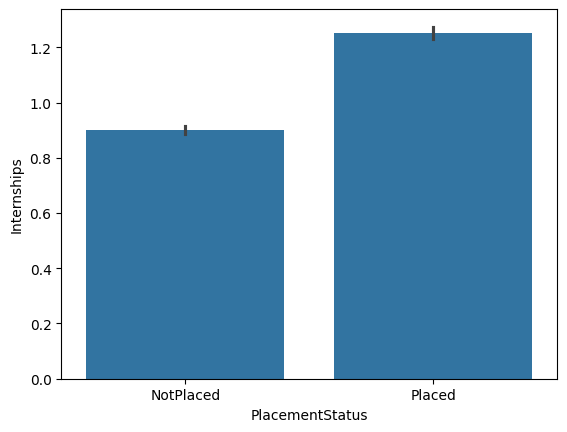

In [27]:
sns.barplot(data=df, x="PlacementStatus", y="Internships")

<Axes: xlabel='PlacementStatus', ylabel='AptitudeTestScore'>

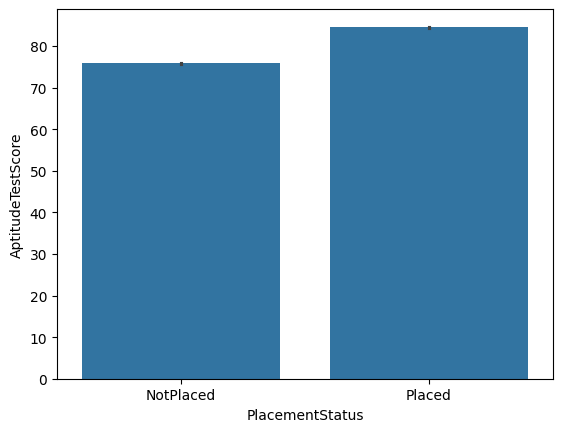

In [28]:
sns.barplot(data=df, x="PlacementStatus", y="AptitudeTestScore")

<Axes: xlabel='PlacementStatus', ylabel='SoftSkillsRating'>

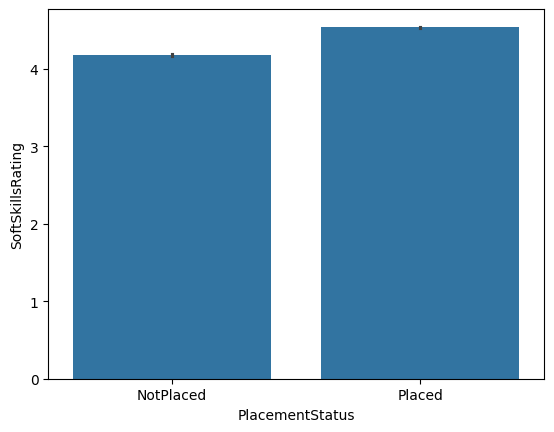

In [29]:
sns.barplot(data=df, x="PlacementStatus", y="SoftSkillsRating")

<Axes: xlabel='PlacementStatus', ylabel='Projects'>

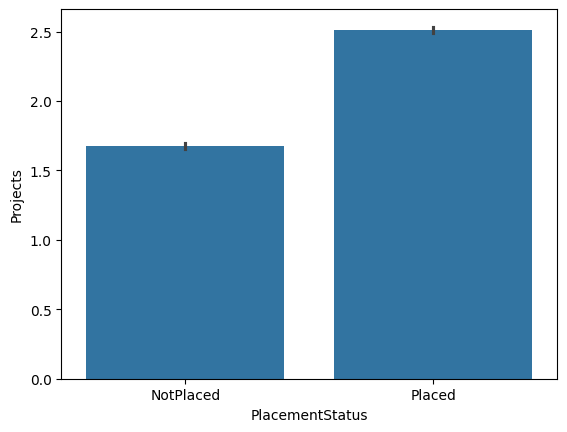

In [30]:
sns.barplot(data=df, x="PlacementStatus", y="Projects")

In [31]:
pd.crosstab(df['PlacementStatus'], df['PlacementTraining'],normalize='index')

PlacementTraining,No,Yes
PlacementStatus,,
NotPlaced,0.390143,0.609857
Placed,0.099595,0.900405


<Axes: xlabel='PlacementTraining', ylabel='count'>

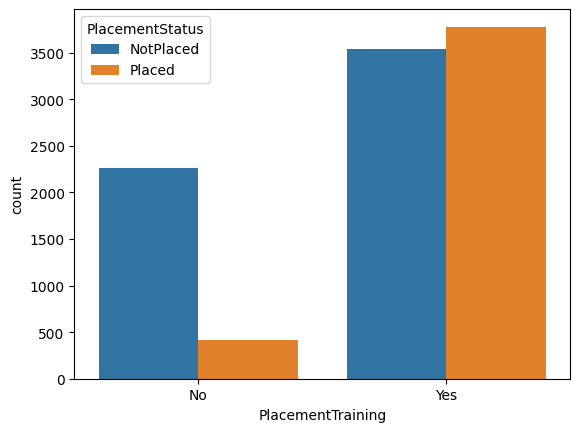

In [32]:
sns.countplot(data=df,x='PlacementTraining',hue='PlacementStatus')

<Axes: xlabel='ExtracurricularActivities', ylabel='count'>

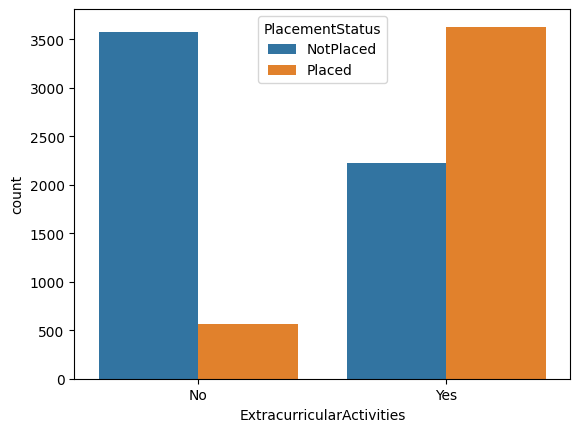

In [33]:
sns.countplot(data=df,x='ExtracurricularActivities',hue='PlacementStatus')

In [ ]:
#percentage of students who got placed based on whether they have undergone placement training or not
pd.crosstab(
    df["PlacementTraining"],
    df["PlacementStatus"],
    normalize="index"
) * 100

PlacementStatus,NotPlaced,Placed
PlacementTraining,,
No,84.414616,15.585384
Yes,48.360208,51.639792


5. PLACEMENT RATE ANALYSIS

In [61]:
#creating cgpa groups for understanding
df['CGPA_Group']=pd.cut(
    df['CGPA'],
    bins=[0,6,7,8,9,10],
    labels=['0-6','6-7','7-8','8-9','9-10']
)

In [63]:
#placement rate based on CGPA groups
placement_rate=pd.crosstab(
    df['CGPA_Group'],
    df['PlacementStatus'],
    normalize="index"
)*100
placement_rate

PlacementStatus,NotPlaced,Placed
CGPA_Group,,
6-7,81.856990,18.143010
7-8,69.512195,30.487805
8-9,30.501274,69.498726
9-10,0.000000,100.000000


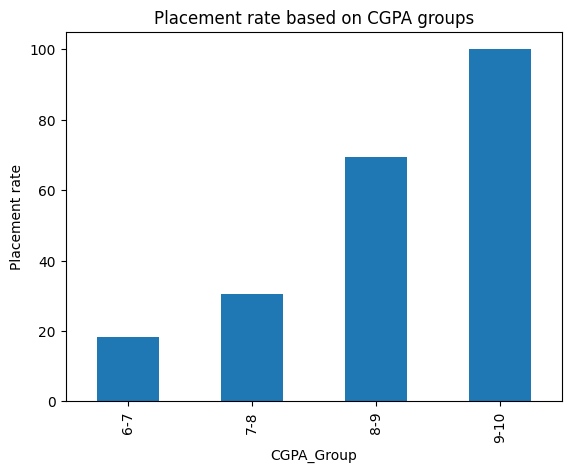

In [64]:
placement_rate['Placed'].plot(kind='bar')
plt.ylabel("Placement rate")
plt.title("Placement rate based on CGPA groups")
plt.show()

In [65]:
pd.crosstab(
    df["Internships"],
    df["PlacementStatus"],
    normalize="index"
) * 100

PlacementStatus,NotPlaced,Placed
Internships,,
0,66.565809,33.434191
1,67.358354,32.641646
2,30.303030,69.696970


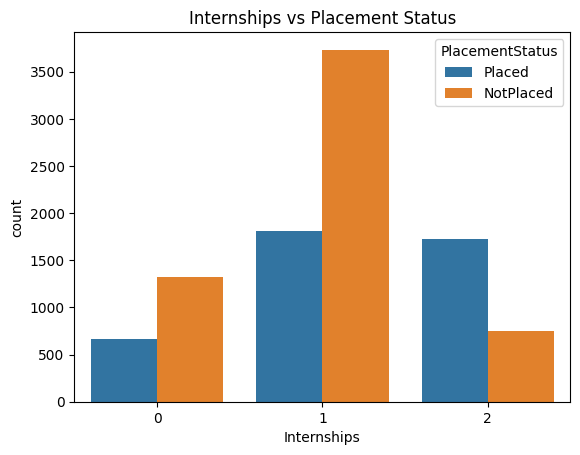

In [66]:
sns.countplot(
    data=df,
    x="Internships",
    hue="PlacementStatus"
)

plt.title("Internships vs Placement Status")
plt.show()

6. EDA FINDINGS

1. The dataset contains 10,000 student records and 12 columns initially.
   StudentID was removed because it is only an identifier and does not
   provide useful information for predicting placement.

2. The dataset contains no missing values and no duplicate records,
   indicating that no major missing-value or duplicate-record treatment
   is required.

3. The target variable, PlacementStatus, contains 5,803 students who
   are NotPlaced and 4,197 students who are Placed. Therefore, the
   dataset is somewhat imbalanced toward the NotPlaced class.

4. The CGPA ranges from 6.5 to 9.1, with a mean of approximately 7.70
   and a median of 7.7. The distribution does not show strong skewness,
   indicating that CGPA is relatively concentrated around its central
   values.

5. Most students have around 1 internship and 2 projects. The median
   number of internships is 1 and the median number of projects is 2.

6. AptitudeTestScore has a mean of approximately 79.45 and ranges from
   60 to 90. This indicates that most students have relatively good
   aptitude scores.

7. The average SoftSkillsRating is approximately 4.32 out of 5, showing
   that most students have relatively high soft-skill ratings.

8. Placement training is fairly common in the dataset: 7,318 students
   have received placement training, while 2,682 have not.

9. Extracurricular activities are also common, with 5,854 students
   participating and 4,146 students not participating.

10. The numerical features show different levels of variation. SSC marks
    have greater spread than CGPA, while CGPA is relatively concentrated
    within a narrow range.

11. The analysis of numerical features against PlacementStatus suggests
    that academic performance, internships, projects, aptitude scores and
    other student attributes should be investigated further to understand
    their relationship with placement outcomes.

12. Overall, the EDA indicates that student placement is likely related
    to a combination of academic performance, skills, experience and
    training rather than a single feature.

classify X and y

In [34]:
y=df['PlacementStatus']

In [35]:
X=df.drop('PlacementStatus',axis=1)

In [36]:
y.shape

(10000,)

In [37]:
X.shape

(10000, 10)

In [38]:
y.shape

(10000,)

In [39]:
#encoding categorical variables 
df['ExtracurricularActivities']=df['ExtracurricularActivities'].map({
    "yes":1,
    'no':0
})

In [40]:
#train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [41]:
categorical_cols = [
    "ExtracurricularActivities",
    "PlacementTraining"
]

numerical_cols = [
    "CGPA",
    "Internships",
    "Projects",
    "Workshops/Certifications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "SSC_Marks",
    "HSC_Marks"
]

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [43]:
preprocessor=ColumnTransformer(
    transformers=[
       ("num",StandardScaler(),numerical_cols),
       ("cat",OneHotEncoder(handle_unknown='ignore'),categorical_cols)
    ]
)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [45]:
logistic_model=Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression())
])

In [46]:
#train
logistic_model.fit(X_train,y_train)
#predict
y_pred=logistic_model.predict(X_test)

EVALUATION

In [47]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
f1_score,confusion_matrix,classification_report)

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred,pos_label="Placed"))
print("Recall:", recall_score(y_test, y_pred,pos_label="Placed"))
print("F1 Score:", f1_score(y_test, y_pred,pos_label="Placed"))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8085
Precision: 0.7695035460992907
Recall: 0.7759237187127532
F1 Score: 0.772700296735905
Confusion Matrix:
[[966 195]
 [188 651]]
Classification Report:
              precision    recall  f1-score   support

   NotPlaced       0.84      0.83      0.83      1161
      Placed       0.77      0.78      0.77       839

    accuracy                           0.81      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.81      0.81      0.81      2000



In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [50]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

In [51]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

In [52]:
predictions = {}

for name, pipeline in pipelines.items():
    predictions[name] = pipeline.predict(X_test)

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, y_pred in predictions.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, pos_label="Placed"
        ),
        "Recall": recall_score(
            y_test, y_pred, pos_label="Placed"
        ),
        "F1 Score": f1_score(
            y_test, y_pred, pos_label="Placed"
        )
    })

In [54]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8085,0.769504,0.775924,0.772700
1,Decision Tree,0.7205,0.671569,0.653159,0.662236
2,Random Forest,0.7900,0.756426,0.736591,0.746377
3,KNN,0.7800,0.741818,0.729440,0.735577
4,SVM,0.8035,0.775309,0.748510,0.761674


In [55]:
from sklearn.model_selection import cross_val_score

for name, pipeline in pipelines.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1_weighted"
    )

    print(f"{name}: {scores.mean():.4f}")

Logistic Regression: 0.7967
Decision Tree: 0.7160
Random Forest: 0.7854
KNN: 0.7707
SVM: 0.7952
